## Feature Engineering 

- in the notebook 02 we have established a clean  baseline performance slightly above random confirming the difficulty of the problem & providing a  reference point for feature engineering and advanced modeling...
- our goal now is to transform weak raw signals into structured features that allow non linear models to exploit regime dependent behavior discovered during EDA

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_train = pd.read_csv("../data/raw/x_train.csv")
y_train = pd.read_csv("../data/raw/y_train.csv")

df = X_train.merge(y_train, on="ID", how="inner")

print("Dataset shape:", df.shape)


Dataset shape: (418595, 48)


In [16]:
#  momentum features 
# Short term momentum
df["RET_mean_5"] = df[[f"RET_{i}" for i in range(1, 6)]].mean(axis=1)

# medium term momentum
df["RET_mean_10"] = df[[f"RET_{i}" for i in range(1, 11)]].mean(axis=1)

# vola features 
df["VOLATILITY_5"] = df[[f"RET_{i}" for i in range(1, 6)]].std(axis=1)
df["VOLATILITY_10"] = df[[f"RET_{i}" for i in range(1, 11)]].std(axis=1)

df[["RET_mean_5", "RET_mean_10", "VOLATILITY_5", "VOLATILITY_10"]].describe()


,RET_mean_5,RET_mean_10,VOLATILITY_5,VOLATILITY_10
count,416339.000000,416348.000000,416271.000000,416316.000000
mean,0.000837,0.000377,0.023089,0.024557
std,0.013412,0.009594,0.021773,0.020083
min,-0.253899,-0.198527,0.000000,0.000000
25%,-0.004651,-0.003562,0.010874,0.012787
50%,0.000687,0.000480,0.017347,0.019246
75%,0.006165,0.004475,0.027766,0.029650
max,0.604759,0.308687,1.394494,0.984020


- momentum features
Means ≈ 0 -->  expected in efficient markets
Reasonable dispersion
No exploding values -->  usable
- Volatility features
Positive  right skewed
Clear separation between 5 day and 10 day horizons
No numerical issues

- We will not reuse string labels  ( low hight ), instead we will ccreat  VOL_REGIME_5 based on VOLATILITY_5 with values:
    - -1 = low vola
    - 0 = medium vola
    -  1 = high vola 


In [17]:
# quantil treshold 
low_thr_5 = df["VOLATILITY_5"].quantile(0.3)
high_thr_5 = df["VOLATILITY_5"].quantile(0.7)

def encode_vol_regime(v, low, high):
    if v <= low:
        return -1
    elif v >= high:
        return 1
    else:
        return 0

df["VOL_REGIME_5"] = df["VOLATILITY_5"].apply(
    lambda v: encode_vol_regime(v, low_thr_5, high_thr_5)
)

df["VOL_REGIME_5"].value_counts().sort_index()


VOL_REGIME_5
-1    124882
 0    168831
 1    124882
Name: count, dtype: int64

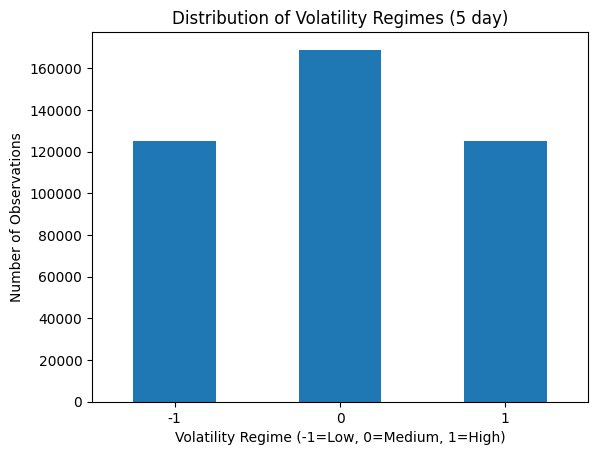

In [18]:
df["VOL_REGIME_5"].value_counts().sort_index().plot(
    kind="bar",
    title="Distribution of Volatility Regimes (5 day)",
    xlabel="Volatility Regime (-1=Low, 0=Medium, 1=High)",
    ylabel="Number of Observations",
    rot=0
)
plt.show()


- symmetric &well balanced
-  volatility regime feature is encoded and suitable for ML models

## feature table

- now we ll prepare  the  feature matrix that will be fed to  models
- We include
    - short & medium momentum
    - Short & medium volatility
    - Volatility regime
    - Raw recent returns (for trees)


In [19]:
feature_cols = (
    [f"RET_{i}" for i in range(1, 6)] +
    [f"VOLUME_{i}" for i in range(1, 6)] +
    ["RET_mean_5", "RET_mean_10", "VOLATILITY_5", "VOLATILITY_10", "VOL_REGIME_5"]
)

X_fe = df[feature_cols].fillna(0)
y = df["RET"]

print("Feature matrix shape:", X_fe.shape)
print("Number of features:", X_fe.shape[1])


Feature matrix shape: (418595, 15)
Number of features: 15


## handoff to modeling frist non lin model

- after EDA + feature eng , we learned that 
    - Signal is weak and conditional
    - Effects are non-linear
    -  Interactions matter (momentum × volatility)
- --> that means we ll use RF first  because it captures non linearities , handles interactions automatically and works without heavy preprocessing

In [20]:
# train validation split
X_train_fe, X_val_fe, y_train_fe, y_val_fe = train_test_split(
    X_fe,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train_fe.shape)
print("Validation shape:", X_val_fe.shape)

Train shape: (334876, 15)
Validation shape: (83719, 15)


In [21]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=50,
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_train_fe, y_train_fe)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",50
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [22]:
# validation performance
y_val_pred_rf = rf_model.predict(X_val_fe)
rf_accuracy = accuracy_score(y_val_fe, y_val_pred_rf)

print("Random Forest validation accuracy:", rf_accuracy)


Random Forest validation accuracy: 0.5245404269042869


- Baseline LR : 50.55%
- RF  + engineered features: 52.45%
- The improvement over the baseline confirms that market behavior is regime-dependent and that non-linear models are required to exploit weak but structured signals in financial data

## Feature importance

In [23]:
# Feature importance from RF

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

feature_importance


VOLUME_1         0.106921
RET_1            0.102769
RET_3            0.086105
VOLATILITY_10    0.081075
VOLATILITY_5     0.080323
RET_4            0.074606
RET_mean_10      0.068842
RET_mean_5       0.066333
RET_5            0.064498
VOLUME_3         0.060440
RET_2            0.058781
VOLUME_2         0.046532
VOLUME_5         0.044496
VOLUME_4         0.042401
VOL_REGIME_5     0.015880
dtype: float64

- The last few dayS returns contain the most predictive information!!! 
- Volatility conditions how returns behave not only the  sign !!

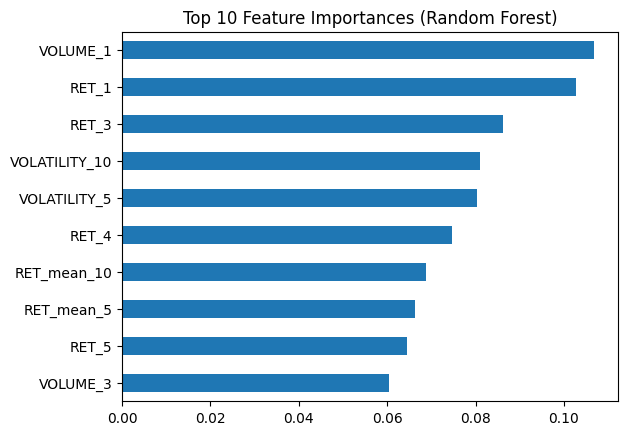

In [24]:
feature_importance.head(10).plot(
    kind="barh",
    title="Top 10 Feature Importances (Random Forest)"
)
plt.gca().invert_yaxis()
plt.show()
